# PROJECT ML  - Peramalan Inflasi Indonesia (Multivariat)
**Target:** `Inflasi_MoM` | **Model:** LSTM & XGBoost | **Split:** 80:20 Temporal

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Alat kerja sudah siap!")

2026-06-12 22:56:56.553390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781305016.810329      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781305016.890090      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781305017.521745      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781305017.521800      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781305017.521805      16 computation_placer.cc:177] computation placer alr

Alat kerja sudah siap!


## Load & Persiapan Data

In [2]:
# Load dataset
df_raw = pd.read_csv('/kaggle/input/datasets/cahndueeso0/mlproject/clean_inflasi_ts (1).csv')

df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'])
df_raw = df_raw.set_index('Tanggal')
df_raw = df_raw.sort_index()

kolom_hapus = ['Bulan', 'Tahun', 'Inflasi_YoY', 'Inflasi_YtD']
kolom_sensitif = ['Inflasi_Umum_MoM', 'Inflasi_Inti_MoM', 'Inflasi_HargaDiatur_MoM', 'Inflasi_Bergejolak_MoM']

df_raw.drop(columns=kolom_hapus + kolom_sensitif, inplace=True)

print(f"Dimensi data: {df_raw.shape}")
print(f"Rentang waktu: {df_raw.index[0].strftime('%b %Y')} hingga {df_raw.index[-1].strftime('%b %Y')}")
print(f"Total observasi: {len(df_raw)} bulan")
print(f"\nKolom dihapus (leakage / redundan): {kolom_hapus}")
print(f"\nKolom yang tersisa ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

Dimensi data: (257, 37)
Rentang waktu: Jan 2005 hingga May 2026
Total observasi: 257 bulan

Kolom dihapus (leakage / redundan): ['Bulan', 'Tahun', 'Inflasi_YoY', 'Inflasi_YtD']

Kolom yang tersisa (37):
['Inflasi_MoM', 'IHK', 'BI_Rate', 'Harga_Minyak_USD', 'Brent_USD', 'DXY', 'FedRate_Pct', 'Gold_USD', 'CPO_USD', 'GPR_Index', 'FAO_FPI', 'CMO_PalmOil_USD', 'CMO_Coal_AU_USD', 'CMO_Coal_SA_USD', 'CMO_Coffee_Robusta_USD', 'CMO_Coffee_Arabica_USD', 'CMO_Wheat_SRW_USD', 'CMO_Wheat_HRW_USD', 'CMO_Soybeans_USD', 'CMO_SoybeanOil_USD', 'CMO_Sugar_USD', 'CMO_Rubber_TSR20_USD', 'CMO_Rubber_RSS3_USD', 'CMO_Cotton_USD', 'CMO_Rice_Thailand_USD', 'CMO_CoconutOil_USD', 'CMO_Groundnuts_USD', 'CMO_FishMeal_USD', 'CMO_Maize_USD', 'CMO_Tin_USD', 'CMO_Nickel_USD', 'CMO_Copper_USD', 'CMO_Aluminum_USD', 'CMO_IronOre_USD', 'CMO_NatGas_USD', 'CMO_NatGas_EU_USD', 'CMO_LNG_Japan_USD']


In [3]:
# Cek nilai hilang
nan_summary = df_raw.isnull().sum()
nan_cols = nan_summary[nan_summary > 0]
if len(nan_cols) > 0:
    print("Kolom dengan NaN:")
    print(nan_cols)
    print("\n[CATATAN] Pengisian NaN ditunda hingga setelah split dan pembuatan Sekuens")
    print("untuk mencegah leakage informasi test set ke train set.")
else:
    print("Tidak ada nilai hilang. Data bersih.")

print(f"\nNaN tersisa sebelum split: {df_raw.isnull().sum().sum()}")


Tidak ada nilai hilang. Data bersih.

NaN tersisa sebelum split: 0


## Eksplorasi Data (EDA)

In [4]:
# Statistik deskriptif target
print("Statistik Deskriptif: Inflasi_MoM")
print(df_raw['Inflasi_MoM'].describe())
print(f"\nNilai Negatif: {(df_raw['Inflasi_MoM'] < 0).sum()} bulan")
print("Log transform TIDAK digunakan karena Inflasi_MoM bisa bernilai negatif.")
print("Normalisasi menggunakan RobustScaler.")

Statistik Deskriptif: Inflasi_MoM
count    257.000000
mean       0.414436
std        0.718040
min       -0.760000
25%        0.080000
50%        0.280000
75%        0.620000
max        8.700000
Name: Inflasi_MoM, dtype: float64

Nilai Negatif: 48 bulan
Log transform TIDAK digunakan karena Inflasi_MoM bisa bernilai negatif.
Normalisasi menggunakan RobustScaler.


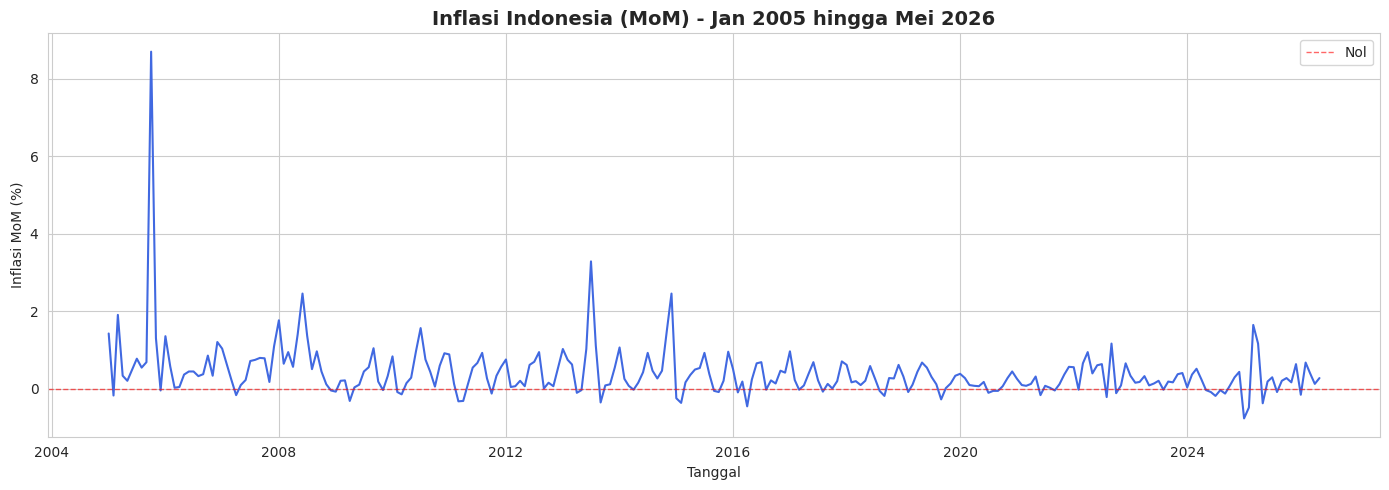

In [5]:
# Plot time series target
plt.figure(figsize=(14, 5))
plt.plot(df_raw.index, df_raw['Inflasi_MoM'], color='royalblue', linewidth=1.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Nol')
plt.title('Inflasi Indonesia (MoM) - Jan 2005 hingga Mei 2026', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Inflasi MoM (%)')
plt.legend()
plt.tight_layout()
plt.show()

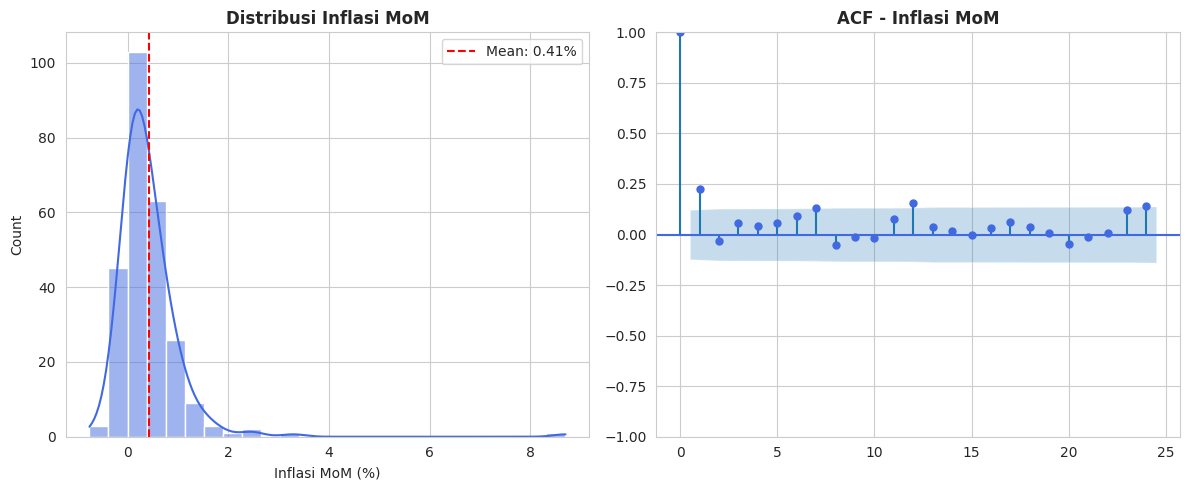

In [6]:
# Distribusi target
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_raw['Inflasi_MoM'], kde=True, color='royalblue', bins=25)
plt.axvline(df_raw['Inflasi_MoM'].mean(), color='red', linestyle='--', label=f"Mean: {df_raw['Inflasi_MoM'].mean():.2f}%")
plt.title('Distribusi Inflasi MoM', fontweight='bold')
plt.xlabel('Inflasi MoM (%)')
plt.legend()

plt.subplot(1, 2, 2)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_raw['Inflasi_MoM'], lags=24, ax=plt.gca(), color='royalblue')
plt.title('ACF - Inflasi MoM', fontweight='bold')

plt.tight_layout()
plt.show()

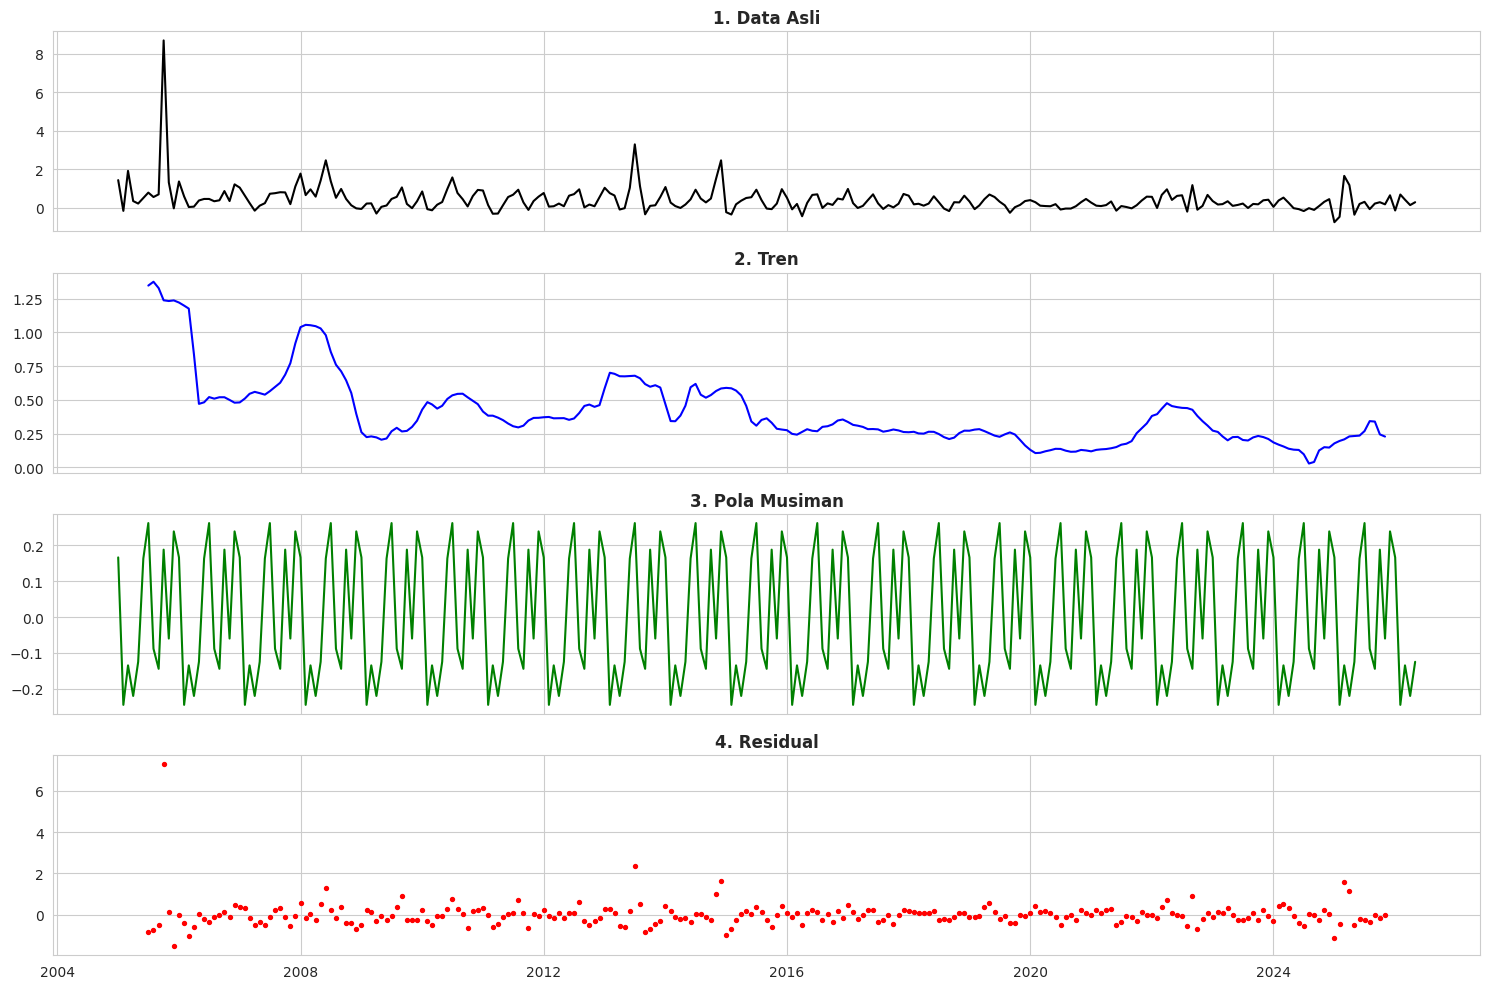

In [7]:
# Dekomposisi musiman
from statsmodels.tsa.seasonal import seasonal_decompose

hasil_bedah = seasonal_decompose(df_raw['Inflasi_MoM'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axes[0].plot(df_raw['Inflasi_MoM'], color='black'); axes[0].set_title('1. Data Asli', fontweight='bold')
axes[1].plot(hasil_bedah.trend, color='blue'); axes[1].set_title('2. Tren', fontweight='bold')
axes[2].plot(hasil_bedah.seasonal, color='green'); axes[2].set_title('3. Pola Musiman', fontweight='bold')
axes[3].scatter(df_raw.index, hasil_bedah.resid, color='red', s=8); axes[3].set_title('4. Residual', fontweight='bold')
plt.tight_layout()
plt.show()

## Pembagian Data (80:20 Temporal)

In [8]:
# Split 80:20 temporal
split_idx     = int(len(df_raw) * 0.8)
tanggal_pisah = df_raw.index[split_idx]

print(f"Total data      : {len(df_raw)} bulan")
print(f"Data Latih (80%): {split_idx} bulan  [{df_raw.index[0].strftime('%b %Y')} — {df_raw.index[split_idx-1].strftime('%b %Y')}]")
print(f"Data Uji   (20%): {len(df_raw) - split_idx} bulan  [{df_raw.index[split_idx].strftime('%b %Y')} — {df_raw.index[-1].strftime('%b %Y')}]")
print(f"\nTanggal pisah   : {tanggal_pisah.strftime('%B %Y')}")

# Imputasi NaN per-partisi SETELAH split — mencegah leakage nilai test ke train
# (forward fill: hanya menggunakan nilai sebelumnya dalam partisi yang sama)
df_train_raw = df_raw[df_raw.index < tanggal_pisah].copy().ffill()
df_test_raw  = df_raw[df_raw.index >= tanggal_pisah].copy().ffill()
df_raw       = pd.concat([df_train_raw, df_test_raw]).sort_index()
print(f"NaN tersisa setelah ffill per-partisi: {df_raw.isnull().sum().sum()}")


Total data      : 257 bulan
Data Latih (80%): 205 bulan  [Jan 2005 — Jan 2022]
Data Uji   (20%): 52 bulan  [Feb 2022 — May 2026]

Tanggal pisah   : February 2022
NaN tersisa setelah ffill per-partisi: 0


## Fungsi (Metrik & Visualisasi)

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Fungsi Metrik 
def hitung_metrik_lengkap(y_asli, y_prediksi):
    y_asli     = np.array(y_asli).flatten()
    y_prediksi = np.array(y_prediksi).flatten()

    rmse  = np.sqrt(mean_squared_error(y_asli, y_prediksi))
    mae   = mean_absolute_error(y_asli, y_prediksi)
    smape = np.mean(
        2 * np.abs(y_asli - y_prediksi) / (np.abs(y_asli) + np.abs(y_prediksi) + 1e-8)
    ) * 100

    return {
        'RMSE'  : rmse,
        'MAE'   : mae,
        'SMAPE%': smape
    }


# Fungsi Visualisasi Evaluasi
def plot_analisis_temporal_inflasi(tanggal, aktual, prediksi, nama_model, warna_prediksi):
    metrik   = hitung_metrik_lengkap(aktual, prediksi)
    residual = aktual - prediksi

    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # Plot Aktual vs Prediksi (Garis Waktu)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(tanggal, aktual, color='black', label='Data Aktual (Test Set)', linewidth=2)
    ax1.plot(tanggal, prediksi, color=warna_prediksi, linestyle='--',
             label=f'Prediksi {nama_model}', linewidth=2, marker='s')
    ax1.fill_between(tanggal, aktual, prediksi, color=warna_prediksi, alpha=0.1, label='Area Selisih (Error)')
    ax1.set_title(f'Prediksi vs Aktual Inflasi MoM ({nama_model})', fontsize=15, fontweight='bold')
    ax1.set_ylabel('Inflasi MoM (%)')
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Scatter Plot
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.scatter(aktual, prediksi, color=warna_prediksi, alpha=0.7, edgecolor='white', s=60)
    lo, hi = min(aktual), max(aktual)
    ax2.plot([lo, hi], [lo, hi], 'k--', label='Garis Ideal')
    teks_metrik = f"MAE: {metrik['MAE']:,.4f}\nRMSE: {metrik['RMSE']:,.4f}\nSMAPE: {metrik['SMAPE%']:.2f}%"
    ax2.text(0.05, 0.95, teks_metrik, transform=ax2.transAxes, va='top',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'), fontsize=12)
    ax2.set_title(f'Scatter Plot Keselarasan ({nama_model})', fontweight='bold')
    ax2.set_xlabel('Nilai Aktual Asli')
    ax2.set_ylabel('Nilai Hasil Prediksi')
    ax2.legend(loc='lower right')

    # Distribusi Residual
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(residual, bins=15, color='orange', alpha=0.7, edgecolor='white')
    ax3.axvline(0, color='black', linestyle='--', linewidth=2, label='Error Nol (Sempurna)')
    ax3.axvline(np.mean(residual), color='red', linestyle=':', linewidth=2,
                label=f'Rata-rata Error: {np.mean(residual):.4f}')
    ax3.set_title(f'Distribusi Kesalahan / Residual ({nama_model})', fontweight='bold')
    ax3.set_xlabel('Nilai Residual (Aktual - Prediksi)')
    ax3.set_ylabel('Frekuensi')
    ax3.legend()

    plt.tight_layout()
    plt.show()


## Model LSTM (Multivariat)


### Persiapan Data LSTM

In [10]:
# Semua kolom dipakai, target di posisi pertama untuk kemudahan inverse transform
kolom_fitur_lstm = ['Inflasi_MoM'] + [c for c in df_raw.columns if c != 'Inflasi_MoM']

data_lstm = df_raw[kolom_fitur_lstm].copy()

# Fitur kalender (siklus bulanan)
data_lstm['bulan_sin'] = np.sin(2 * np.pi * data_lstm.index.month / 12.0)
data_lstm['bulan_cos'] = np.cos(2 * np.pi * data_lstm.index.month / 12.0)

n_fitur_lstm = data_lstm.shape[1]
print(f"Jumlah fitur input LSTM: {n_fitur_lstm}")
print(f"Kolom: {data_lstm.columns.tolist()}")

Jumlah fitur input LSTM: 39
Kolom: ['Inflasi_MoM', 'IHK', 'BI_Rate', 'Harga_Minyak_USD', 'Brent_USD', 'DXY', 'FedRate_Pct', 'Gold_USD', 'CPO_USD', 'GPR_Index', 'FAO_FPI', 'CMO_PalmOil_USD', 'CMO_Coal_AU_USD', 'CMO_Coal_SA_USD', 'CMO_Coffee_Robusta_USD', 'CMO_Coffee_Arabica_USD', 'CMO_Wheat_SRW_USD', 'CMO_Wheat_HRW_USD', 'CMO_Soybeans_USD', 'CMO_SoybeanOil_USD', 'CMO_Sugar_USD', 'CMO_Rubber_TSR20_USD', 'CMO_Rubber_RSS3_USD', 'CMO_Cotton_USD', 'CMO_Rice_Thailand_USD', 'CMO_CoconutOil_USD', 'CMO_Groundnuts_USD', 'CMO_FishMeal_USD', 'CMO_Maize_USD', 'CMO_Tin_USD', 'CMO_Nickel_USD', 'CMO_Copper_USD', 'CMO_Aluminum_USD', 'CMO_IronOre_USD', 'CMO_NatGas_USD', 'CMO_NatGas_EU_USD', 'CMO_LNG_Japan_USD', 'bulan_sin', 'bulan_cos']


### Split Data LSTM

In [11]:
jumlah_bulan_kebelakang = 12  # lookback window

# Tarik mundur batas awal data uji sebesar lookback agar sekuens pertama test
# tepat meramal bulan pertama test set (tanggal_pisah)
tanggal_awal_uji_lstm = tanggal_pisah - pd.DateOffset(months=jumlah_bulan_kebelakang)

data_latih_lstm = data_lstm[data_lstm.index < tanggal_pisah].copy()
data_uji_lstm   = data_lstm[data_lstm.index >= tanggal_awal_uji_lstm].copy()

print(f"Data latih LSTM : {len(data_latih_lstm)} bulan  [{data_latih_lstm.index[0].strftime('%b %Y')} — {data_latih_lstm.index[-1].strftime('%b %Y')}]")
print(f"Data uji LSTM   : {len(data_uji_lstm)} bulan   [{data_uji_lstm.index[0].strftime('%b %Y')} — {data_uji_lstm.index[-1].strftime('%b %Y')}]")
print(f"Lookback window : {jumlah_bulan_kebelakang} bulan")
print(f"Prediksi uji pertama jatuh di: {tanggal_pisah.strftime('%B %Y')} ✓")

Data latih LSTM : 205 bulan  [Jan 2005 — Jan 2022]
Data uji LSTM   : 64 bulan   [Feb 2021 — May 2026]
Lookback window : 12 bulan
Prediksi uji pertama jatuh di: February 2022 ✓


### Fungsi Pembuatan Sekuens

In [12]:
def buat_urutan_data(data_input, lookback=12):
    """
    Membuat pasangan (X, y) dari data time series multivariat.
    X: window lookback dari semua fitur
    y: nilai target (kolom 0 = Inflasi_MoM) pada timestep berikutnya
    """
    X, y = [], []
    for i in range(len(data_input) - lookback):
        X.append(data_input[i : i + lookback])
        y.append(data_input[i + lookback, 0])  # kolom 0 = Inflasi_MoM
    return np.array(X), np.array(y)

### Grid Search LSTM

In [13]:
pilihan_pengaturan_lstm = {
    'units'         : [16, 32, 64],   
    'dropout'       : [0.1, 0.2],     
    'learning_rate' : [0.001, 0.005],
    'batch_size'    : [8, 16, 32]   
}

pembagi_waktu_cv = TimeSeriesSplit(n_splits=3) 
kombinasi_grid   = ParameterGrid(pilihan_pengaturan_lstm)

skor_error_terendah    = float('inf')
pengaturan_terbaik_lstm = None

print("Proses Grid Search LSTM ...")

for pengaturan in kombinasi_grid:
    print(f"Mencoba: {pengaturan}")
    kumpulan_skor = []

    for idx_latih, idx_val in pembagi_waktu_cv.split(data_latih_lstm):
        potongan_latih = data_latih_lstm.values[idx_latih]
        potongan_val   = data_latih_lstm.values[idx_val]

        # Scaling di dalam loop 
        scaler_sementara = RobustScaler()
        latih_skala = scaler_sementara.fit_transform(potongan_latih)
        val_skala   = scaler_sementara.transform(potongan_val)

        X_latih_cv, y_latih_cv = buat_urutan_data(latih_skala, jumlah_bulan_kebelakang)
        X_val_cv,   y_val_cv   = buat_urutan_data(val_skala,   jumlah_bulan_kebelakang)

        if len(X_latih_cv) == 0 or len(X_val_cv) == 0:
            continue

        # 1 layer
        model_cv = Sequential([
            Input(shape=(jumlah_bulan_kebelakang, n_fitur_lstm)),
            LSTM(pengaturan['units'], activation='tanh', kernel_regularizer=l2(0.001)),
            Dropout(pengaturan['dropout']),
            Dense(1)
        ])
        
        model_cv.compile(optimizer=Adam(learning_rate=pengaturan['learning_rate']), loss='mse')

        rem = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                                        min_lr=1e-5, verbose=0)

        # Epoch bisa dinaikkan sedikit karena sudah dilindungi EarlyStopping
        model_cv.fit(X_latih_cv, y_latih_cv,
                     validation_data=(X_val_cv, y_val_cv),
                     epochs=300, batch_size=pengaturan['batch_size'],
                     callbacks=[rem, lr_reducer], verbose=0)

        pred_cv = model_cv.predict(X_val_cv, verbose=0)
        kumpulan_skor.append(mean_squared_error(y_val_cv, pred_cv))

    if len(kumpulan_skor) == 0:
        continue
    
    rata_rata_error = np.mean(kumpulan_skor)
    print(f" Rata-rata MSE Validasi: {rata_rata_error:.6f}")

    if rata_rata_error < skor_error_terendah:
        skor_error_terendah    = rata_rata_error
        pengaturan_terbaik_lstm = pengaturan

print("\n Parameter Terbaik LSTM:", pengaturan_terbaik_lstm)

Proses Grid Search LSTM ...
Mencoba: {'batch_size': 8, 'dropout': 0.1, 'learning_rate': 0.001, 'units': 16}


2026-06-12 22:57:15.673978: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 Rata-rata MSE Validasi: 0.492884
Mencoba: {'batch_size': 8, 'dropout': 0.1, 'learning_rate': 0.001, 'units': 32}
 Rata-rata MSE Validasi: 0.505621
Mencoba: {'batch_size': 8, 'dropout': 0.1, 'learning_rate': 0.001, 'units': 64}
 Rata-rata MSE Validasi: 0.481262
Mencoba: {'batch_size': 8, 'dropout': 0.1, 'learning_rate': 0.005, 'units': 16}
 Rata-rata MSE Validasi: 0.529353
Mencoba: {'batch_size': 8, 'dropout': 0.1, 'learning_rate': 0.005, 'units': 32}
 Rata-rata MSE Validasi: 0.499723
Mencoba: {'batch_size': 8, 'dropout': 0.1, 'learning_rate': 0.005, 'units': 64}
 Rata-rata MSE Validasi: 0.521412
Mencoba: {'batch_size': 8, 'dropout': 0.2, 'learning_rate': 0.001, 'units': 16}
 Rata-rata MSE Validasi: 0.625791
Mencoba: {'batch_size': 8, 'dropout': 0.2, 'learning_rate': 0.001, 'units': 32}
 Rata-rata MSE Validasi: 0.619721
Mencoba: {'batch_size': 8, 'dropout': 0.2, 'learning_rate': 0.001, 'units': 64}
 Rata-rata MSE Validasi: 0.484954
Mencoba: {'batch_size': 8, 'dropout': 0.2, 'learning_r

### Training Final LSTM

In [14]:
# Scaling final — fit hanya pada data latih
alat_skala_final_lstm = RobustScaler()
latih_full_skala = alat_skala_final_lstm.fit_transform(data_latih_lstm.values)
uji_skala        = alat_skala_final_lstm.transform(data_uji_lstm.values)

X_latih_full, y_latih_full = buat_urutan_data(latih_full_skala, jumlah_bulan_kebelakang)
X_uji_lstm,   y_uji_lstm   = buat_urutan_data(uji_skala,        jumlah_bulan_kebelakang)

# memisahkan 15% akhir data latih sebagai validation set Early Stopping
n_pengawas    = int(len(X_latih_full) * 0.15)
X_latih_final = X_latih_full[:-n_pengawas]
y_latih_final = y_latih_full[:-n_pengawas]
X_pengawas    = X_latih_full[-n_pengawas:]
y_pengawas    = y_latih_full[-n_pengawas:]

# membangun model final dengan hyperparameter terbaik
model_terbaik_lstm = Sequential([
    Input(shape=(jumlah_bulan_kebelakang, n_fitur_lstm)),
    LSTM(pengaturan_terbaik_lstm['units'], activation='tanh', 
         kernel_regularizer=l2(0.001)),
    Dropout(pengaturan_terbaik_lstm['dropout']),
    Dense(1)
])

model_terbaik_lstm.compile(
    optimizer=Adam(learning_rate=pengaturan_terbaik_lstm['learning_rate']),
    loss='mse'
)

pengawas_berhenti = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
turunkan_kecepatan = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                                        min_lr=1e-5, verbose=0)

print("\n Proses Training Final LSTM...")
riwayat_pelatihan = model_terbaik_lstm.fit(
    X_latih_final, y_latih_final,
    validation_data=(X_pengawas, y_pengawas),
    epochs=300, # Epoch besar aman karena ada EarlyStopping
    batch_size=pengaturan_terbaik_lstm['batch_size'],
    callbacks=[pengawas_berhenti, turunkan_kecepatan],
    verbose=1
)
print("Training LSTM SELESAI!")


 Proses Training Final LSTM...
Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 1.0137 - val_loss: 0.2407 - learning_rate: 0.0010
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9180 - val_loss: 0.2525 - learning_rate: 0.0010
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8556 - val_loss: 0.2204 - learning_rate: 0.0010
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8047 - val_loss: 0.2207 - learning_rate: 0.0010
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8007 - val_loss: 0.2421 - learning_rate: 0.0010
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7852 - val_loss: 0.2216 - learning_rate: 0.0010
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7630 - val_loss: 0.2216 - learning_rate: 0.0010
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7607 - val_loss: 0.2146 - learning_rate: 0.0010
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7574 - val_loss: 0.2114 - 

In [15]:
# Fungsi inverse transform
def kembalikan_ke_asli_inflasi(data_tebakan_skala, alat_skala_obj):
    n_fitur = alat_skala_obj.n_features_in_
    tabel_bantuan = np.zeros((len(data_tebakan_skala), n_fitur))
    tabel_bantuan[:, 0] = data_tebakan_skala.ravel()
    return alat_skala_obj.inverse_transform(tabel_bantuan)[:, 0]

# Prediksi test set LSTM
tebakan_lstm_skala  = model_terbaik_lstm.predict(X_uji_lstm, verbose=0)
tebakan_lstm_asli   = kembalikan_ke_asli_inflasi(tebakan_lstm_skala, alat_skala_final_lstm)
jawaban_benar_lstm  = kembalikan_ke_asli_inflasi(y_uji_lstm.reshape(-1, 1), alat_skala_final_lstm)

# Index tanggal untuk test set LSTM
indeks_uji_lstm = data_uji_lstm.index[jumlah_bulan_kebelakang:]

# Preview hasil (tabel resmi dibuat di cell Export & Visualisasi)
print(pd.DataFrame({
    'Data Aktual'        : jawaban_benar_lstm,
    'Prediksi Model LSTM': tebakan_lstm_asli
}, index=indeks_uji_lstm))


            Data Aktual  Prediksi Model LSTM
Tanggal                                     
2022-02-01        -0.02             0.414736
2022-03-01         0.66             0.327691
2022-04-01         0.95             0.264282
2022-05-01         0.40             0.333820
2022-06-01         0.61             0.337605
2022-07-01         0.64             0.330703
2022-08-01        -0.21             0.374383
2022-09-01         1.17             0.430436
2022-10-01        -0.11             0.438152
2022-11-01         0.09             0.405172
2022-12-01         0.66             0.371711
2023-01-01         0.34             0.388561
2023-02-01         0.16             0.374391
2023-03-01         0.18             0.350588
2023-04-01         0.33             0.391196
2023-05-01         0.09             0.396978
2023-06-01         0.14             0.410529
2023-07-01         0.21             0.405810
2023-08-01        -0.02             0.389864
2023-09-01         0.19             0.371198
2023-10-01

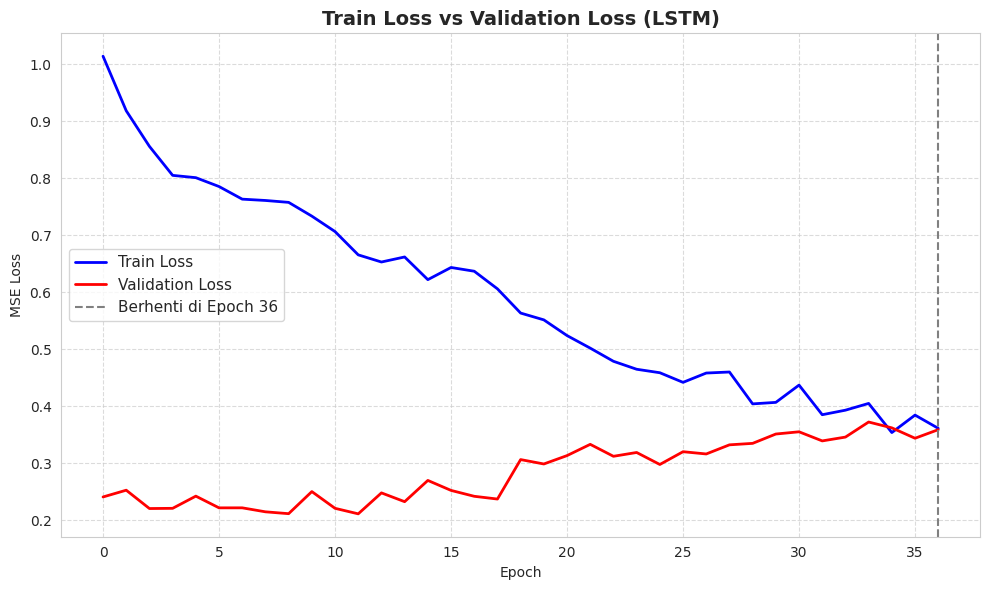

In [16]:
# Plot Train vs Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(riwayat_pelatihan.history['loss'],     label='Train Loss',      color='blue',  linewidth=2)
plt.plot(riwayat_pelatihan.history['val_loss'], label='Validation Loss', color='red',   linewidth=2)
titik_berhenti = len(riwayat_pelatihan.history['loss']) - 1
plt.axvline(x=titik_berhenti, color='gray', linestyle='dashed',
            label=f'Berhenti di Epoch {titik_berhenti}')
plt.title('Train Loss vs Validation Loss (LSTM)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Model XGBoost (Multivariat)
> Fitur multivariat langsung dipakai bersama lag, rolling, dan fitur kalender.

### Feature Engineering XGBoost

In [17]:
import numpy as np

# Ambil target (y)
y_target_xgb = df_raw['Inflasi_MoM']

# Data Fitur (X)
X_fitur_xgb = df_raw.drop(columns=['Inflasi_MoM']).shift(1)

# Fitur Kalender untuk waktu T 
X_fitur_xgb['kuartal']   = X_fitur_xgb.index.quarter
X_fitur_xgb['bulan_sin'] = np.sin(2 * np.pi * X_fitur_xgb.index.month / 12.0)
X_fitur_xgb['bulan_cos'] = np.cos(2 * np.pi * X_fitur_xgb.index.month / 12.0)

# Lag Fitur Target (Murni masa lalu)
for i in [1, 2, 3, 6, 12]:
    X_fitur_xgb[f'inflasi_lag_{i}'] = y_target_xgb.shift(i)

#  Rolling Statistics dari Target
X_fitur_xgb['inflasi_rolling_mean_3']  = y_target_xgb.shift(1).rolling(3).mean()
X_fitur_xgb['inflasi_rolling_std_3']   = y_target_xgb.shift(1).rolling(3).std()
X_fitur_xgb['inflasi_rolling_mean_6']  = y_target_xgb.shift(1).rolling(6).mean()
X_fitur_xgb['inflasi_rolling_std_6']   = y_target_xgb.shift(1).rolling(6).std()
X_fitur_xgb['inflasi_rolling_mean_12'] = y_target_xgb.shift(1).rolling(12).mean()

# Sinkronisasi X dan y (Hapus baris yang mengandung NaN akibat shift/lag)
X_fitur_xgb = X_fitur_xgb.dropna()
y_target_xgb = y_target_xgb.loc[X_fitur_xgb.index]

# Cek Hasil
print(f"Fitur XGBoost  : {X_fitur_xgb.shape[1]} kolom")
print(f"Observasi valid: {len(X_fitur_xgb)} baris (setelah dropna)")
print(f"\nDaftar fitur yang siap ditraining:")
print(X_fitur_xgb.columns.tolist())

Fitur XGBoost  : 49 kolom
Observasi valid: 245 baris (setelah dropna)

Daftar fitur yang siap ditraining:
['IHK', 'BI_Rate', 'Harga_Minyak_USD', 'Brent_USD', 'DXY', 'FedRate_Pct', 'Gold_USD', 'CPO_USD', 'GPR_Index', 'FAO_FPI', 'CMO_PalmOil_USD', 'CMO_Coal_AU_USD', 'CMO_Coal_SA_USD', 'CMO_Coffee_Robusta_USD', 'CMO_Coffee_Arabica_USD', 'CMO_Wheat_SRW_USD', 'CMO_Wheat_HRW_USD', 'CMO_Soybeans_USD', 'CMO_SoybeanOil_USD', 'CMO_Sugar_USD', 'CMO_Rubber_TSR20_USD', 'CMO_Rubber_RSS3_USD', 'CMO_Cotton_USD', 'CMO_Rice_Thailand_USD', 'CMO_CoconutOil_USD', 'CMO_Groundnuts_USD', 'CMO_FishMeal_USD', 'CMO_Maize_USD', 'CMO_Tin_USD', 'CMO_Nickel_USD', 'CMO_Copper_USD', 'CMO_Aluminum_USD', 'CMO_IronOre_USD', 'CMO_NatGas_USD', 'CMO_NatGas_EU_USD', 'CMO_LNG_Japan_USD', 'kuartal', 'bulan_sin', 'bulan_cos', 'inflasi_lag_1', 'inflasi_lag_2', 'inflasi_lag_3', 'inflasi_lag_6', 'inflasi_lag_12', 'inflasi_rolling_mean_3', 'inflasi_rolling_std_3', 'inflasi_rolling_mean_6', 'inflasi_rolling_std_6', 'inflasi_rolling_

### Split Data XGBoost

In [18]:
X_latih_xgb = X_fitur_xgb[X_fitur_xgb.index < tanggal_pisah]
X_uji_xgb   = X_fitur_xgb[X_fitur_xgb.index >= tanggal_pisah]

y_latih_xgb = y_target_xgb[y_target_xgb.index < tanggal_pisah]
y_uji_xgb   = y_target_xgb[y_target_xgb.index >= tanggal_pisah]

print(f"Data latih XGBoost: {len(X_latih_xgb)} bulan  [{X_latih_xgb.index[0].strftime('%b %Y')} — {X_latih_xgb.index[-1].strftime('%b %Y')}]")
print(f"Data uji   XGBoost: {len(X_uji_xgb)} bulan   [{X_uji_xgb.index[0].strftime('%b %Y')} — {X_uji_xgb.index[-1].strftime('%b %Y')}]")

Data latih XGBoost: 193 bulan  [Jan 2006 — Jan 2022]
Data uji   XGBoost: 52 bulan   [Feb 2022 — May 2026]


### Grid Search XGBoost

In [19]:
jalur_pipa_xgb = Pipeline([
    ('perata_skala', RobustScaler()),
    ('mesin_xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

pilihan_pengaturan_xgb = {
    'mesin_xgb__n_estimators': [200, 300, 500],
    'mesin_xgb__max_depth': [2, 3, 4],               
    'mesin_xgb__learning_rate': [0.01, 0.05],     
    'mesin_xgb__subsample': [0.7, 0.8],           
    'mesin_xgb__colsample_bytree': [0.6, 0.8],    
    'mesin_xgb__reg_lambda': [1, 5, 10],          
    'mesin_xgb__gamma': [0.1, 0.5]               
}

pembagi_waktu_xgb = TimeSeriesSplit(n_splits=3)

pencari_xgb = GridSearchCV(
    estimator  = jalur_pipa_xgb,
    param_grid = pilihan_pengaturan_xgb,
    cv         = pembagi_waktu_xgb,
    scoring    = 'neg_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

print("\nGrid Search XGBoost...")
pencari_xgb.fit(X_latih_xgb, y_latih_xgb)
print("\n Parameter terbaik XGBoost:")
print(pencari_xgb.best_params_)

model_terbaik_xgb = pencari_xgb.best_estimator_

# Prediksi test set
tebakan_xgb_asli      = model_terbaik_xgb.predict(X_uji_xgb)
jawaban_benar_xgb     = y_uji_xgb.values

# Preview hasil (tabel resmi dibuat di cell Export & Visualisasi)
print("\n Selesai Training XGBoost!")
print(pd.DataFrame({
    'Data Aktual'           : jawaban_benar_xgb,
    'Prediksi Model XGBoost': tebakan_xgb_asli
}, index=y_uji_xgb.index))


Grid Search XGBoost...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits

 Parameter terbaik XGBoost:
{'mesin_xgb__colsample_bytree': 0.8, 'mesin_xgb__gamma': 0.5, 'mesin_xgb__learning_rate': 0.05, 'mesin_xgb__max_depth': 2, 'mesin_xgb__n_estimators': 200, 'mesin_xgb__reg_lambda': 10, 'mesin_xgb__subsample': 0.7}

 Selesai Training XGBoost!
            Data Aktual  Prediksi Model XGBoost
Tanggal                                        
2022-02-01        -0.02                0.249975
2022-03-01         0.66                0.024111
2022-04-01         0.95                0.316842
2022-05-01         0.40                0.587139
2022-06-01         0.61                0.494350
2022-07-01         0.64                0.599774
2022-08-01        -0.21                0.421850
2022-09-01         1.17                0.193621
2022-10-01        -0.11                0.965566
2022-11-01         0.09                0.341610
2022-12-01         0.66                0.520832
2023-01-01        

## Fitur Terbaik

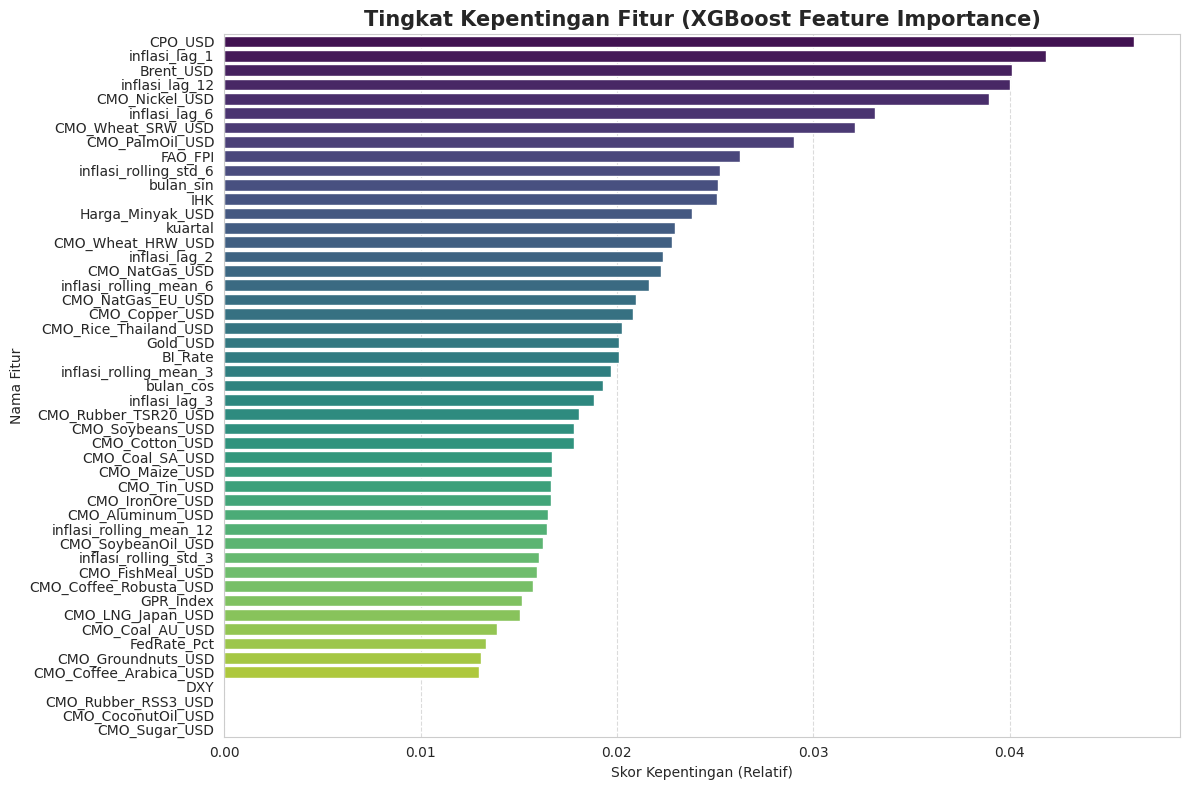


Detail Skor Kepentingan Fitur:


,Fitur,Skor_Kepentingan
7,CPO_USD,0.046357
39,inflasi_lag_1,0.041862
3,Brent_USD,0.040120
43,inflasi_lag_12,0.040032
29,CMO_Nickel_USD,0.038969
42,inflasi_lag_6,0.033159
15,CMO_Wheat_SRW_USD,0.032118
10,CMO_PalmOil_USD,0.029015
9,FAO_FPI,0.026251
47,inflasi_rolling_std_6,0.025260


In [20]:
# Ekstrak model XGBoost dari dalam Pipeline
model_xgb_inti = model_terbaik_xgb.named_steps['mesin_xgb']

#nilai bobot kepentingan fitur
bobot_fitur = model_xgb_inti.feature_importances_

#DataFrame agar rapi dan urutkan dari yang paling penting
tabel_penting = pd.DataFrame({
    'Fitur': X_fitur_xgb.columns,
    'Skor_Kepentingan': bobot_fitur
}).sort_values(by='Skor_Kepentingan', ascending=False)

 
plt.figure(figsize=(12, 8))
sns.barplot(x='Skor_Kepentingan', y='Fitur', data=tabel_penting, palette='viridis')
plt.title('Tingkat Kepentingan Fitur (XGBoost Feature Importance)', fontsize=15, fontweight='bold')
plt.xlabel('Skor Kepentingan (Relatif)')
plt.ylabel('Nama Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("\nDetail Skor Kepentingan Fitur:")
display(tabel_penting)

## Mennyimpanan Model untuk Deployment

In [21]:
model_terbaik_lstm.save('model_lstm_inflasi.h5')
print("Model LSTM tersimpan sebagai 'model_lstm_inflasi.h5'")

Model LSTM tersimpan sebagai 'model_lstm_inflasi.h5'


In [22]:
import joblib
joblib.dump(model_terbaik_xgb, 'model_xgboost_inflasi.joblib')
print("Model XGBoost tersimpan sebagai 'model_xgboost_inflasi.joblib'")

Model XGBoost tersimpan sebagai 'model_xgboost_inflasi.joblib'


## Evaluasi Metrik (Train vs Test)

In [23]:
print("Memproses Evaluasi Metrik pada Data Uji (Test Set)...")


# Evaluasi LSTM (Inverse Transform)
# Melakukan prediksi dengan model LSTM pada data uji
tebakan_lstm_skala = model_terbaik_lstm.predict(X_uji_lstm, verbose=0)

# Mengembalikan prediksi ke skala Inflasi asli
tebakan_lstm_asli = kembalikan_ke_asli_inflasi(tebakan_lstm_skala.reshape(-1, 1), alat_skala_final_lstm)

# Mengambil nilai target aktual (y_uji_lstm) dan mengembalikannya ke skala asli
# Memastikan bentuknya 2D sebelum masuk ke fungsi inverse
if hasattr(y_uji_lstm, 'values'):
    jawaban_benar_lstm_skala = y_uji_lstm.values.reshape(-1, 1)
else:
    jawaban_benar_lstm_skala = y_uji_lstm.reshape(-1, 1)
    
jawaban_benar_lstm_asli = kembalikan_ke_asli_inflasi(jawaban_benar_lstm_skala, alat_skala_final_lstm)

# Evaluasi XGBoost (Sudah Skala Asli)
tebakan_xgb_asli = model_terbaik_xgb.predict(X_uji_xgb)
jawaban_benar_xgb_asli = y_uji_xgb.values

# menghitung Metrik Secara Objektif
metrik_lstm = hitung_metrik_lengkap(jawaban_benar_lstm_asli, tebakan_lstm_asli)
metrik_xgb  = hitung_metrik_lengkap(jawaban_benar_xgb_asli, tebakan_xgb_asli)

# Gabungkan ke dalam Tabel DataFrame
tabel_metrik_test = pd.DataFrame({
    'LSTM (Deep Learning)': metrik_lstm,
    'XGBoost (Tree-based)': metrik_xgb
}).T

print("\n--- TABEL EVALUASI METRIK FINAL (TEST SET) ---")
display(tabel_metrik_test)

Memproses Evaluasi Metrik pada Data Uji (Test Set)...

--- TABEL EVALUASI METRIK FINAL (TEST SET) ---


,RMSE,MAE,SMAPE%
LSTM (Deep Learning),0.468473,0.367544,100.350301
XGBoost (Tree-based),0.466485,0.336008,101.036420


## Visualisasi

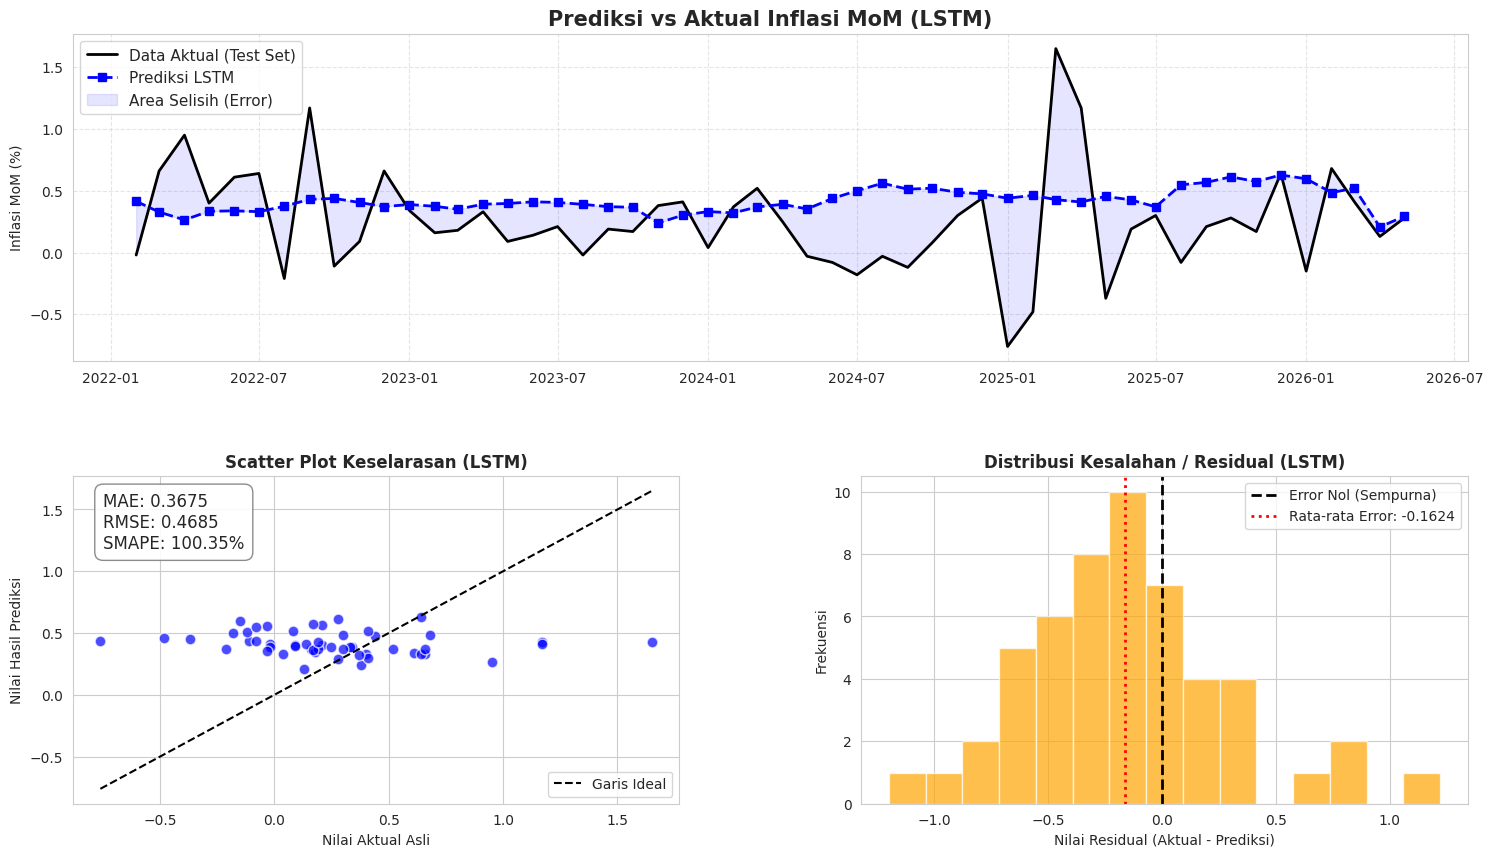

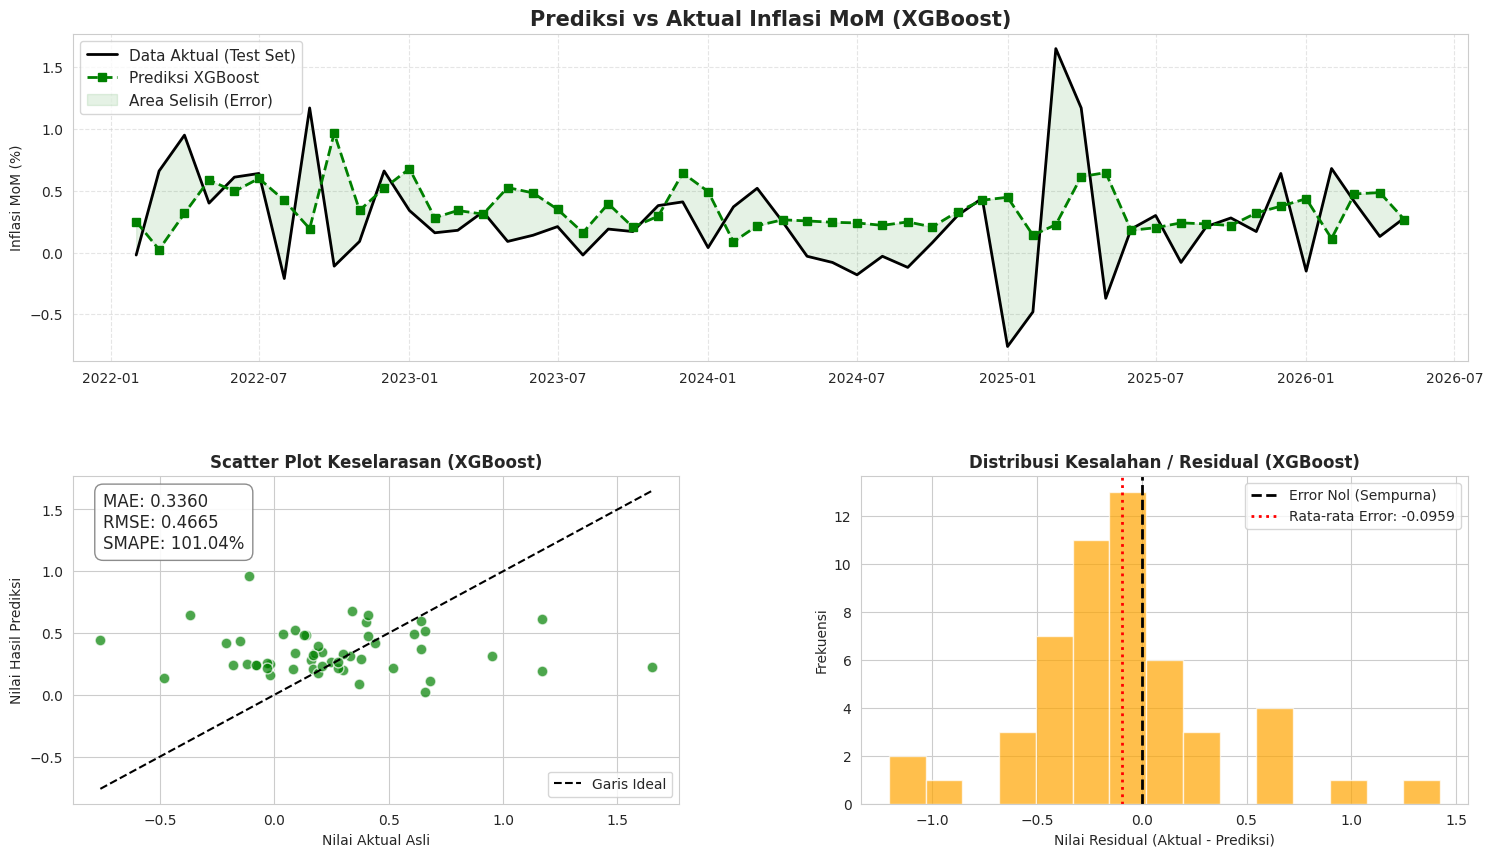

In [24]:
# Visualisasi evaluasi test set — menggunakan variabel dari cell evaluasi (cell 42)
# agar konsisten dengan tabel metrik yang sudah dihitung di atas
plot_analisis_temporal_inflasi(indeks_uji_lstm,  jawaban_benar_lstm_asli, tebakan_lstm_asli,  "LSTM",    "blue")
plot_analisis_temporal_inflasi(y_uji_xgb.index, jawaban_benar_xgb_asli,  tebakan_xgb_asli,  "XGBoost", "green")


In [25]:
# Membuat kalender 12 bulan ke depan dari tanggal terakhir data
tanggal_terakhir = df_raw.index[-1]
kalender_masa_depan = pd.date_range(start=tanggal_terakhir + pd.DateOffset(months=1), periods=12, freq='MS')

# ==========================================================
# 1. FORECAST 12 BULAN DENGAN LSTM
# ==========================================================
idx_bulan_sin = data_lstm.columns.get_loc('bulan_sin')
idx_bulan_cos = data_lstm.columns.get_loc('bulan_cos')

urutan_terakhir_lstm = uji_skala[-jumlah_bulan_kebelakang:].copy()
hasil_ramalan_lstm_skala = []

for tanggal in kalender_masa_depan:
    # Tebak bulan depan berdasarkan memori terakhir
    input_ramalan = urutan_terakhir_lstm.reshape(1, jumlah_bulan_kebelakang, n_fitur_lstm)
    tebakan = model_terbaik_lstm.predict(input_ramalan, verbose=0)
    hasil_ramalan_lstm_skala.append(tebakan[0, 0])

    # Informasi bulan (Sin/Cos) mentah untuk bulan depan
    sin_baru = np.sin(2 * np.pi * tanggal.month / 12.0)
    cos_baru = np.cos(2 * np.pi * tanggal.month / 12.0)

    # Buat matriks dummy sesuai dimensi scaler asli untuk menghindari ValueError
    baris_dummy_asli = np.zeros((1, alat_skala_final_lstm.n_features_in_))
    baris_dummy_asli[0, idx_bulan_sin] = sin_baru
    baris_dummy_asli[0, idx_bulan_cos] = cos_baru
    
    # Scaling pada matriks dummy
    baris_dummy_skala = alat_skala_final_lstm.transform(baris_dummy_asli)
    sin_baru_skala = baris_dummy_skala[0, idx_bulan_sin]
    cos_baru_skala = baris_dummy_skala[0, idx_bulan_cos]

    # Ambil baris terakhir dari sequence untuk mempertahankan nilai konstan fitur eksternal
    informasi_bulan_baru = urutan_terakhir_lstm[-1:, :].copy() 
    
    # Timpa nilai target dan kalender dengan nilai prediksi masa depan
    informasi_bulan_baru[0, 0] = tebakan[0, 0]
    informasi_bulan_baru[0, idx_bulan_sin] = sin_baru_skala
    informasi_bulan_baru[0, idx_bulan_cos] = cos_baru_skala

    # Memasukkan hasil tebakan berskala ke antrean
    urutan_terakhir_lstm = np.append(urutan_terakhir_lstm[1:], informasi_bulan_baru, axis=0)

# Kembalikan ke nilai inflasi asli
ramalan_lstm_asli = kembalikan_ke_asli_inflasi(np.array(hasil_ramalan_lstm_skala).reshape(-1, 1), alat_skala_final_lstm)
tabel_ramalan_lstm = pd.DataFrame({'Ramalan_LSTM': ramalan_lstm_asli}, index=kalender_masa_depan)


# ==========================================================
# 2. FORECAST 12 BULAN DENGAN XGBOOST
# ==========================================================
data_histori_target = df_raw['Inflasi_MoM'].copy()
# Ekstrak nilai terakhir dari fitur eksternal (dianggap konstan untuk peramalan masa depan)
fitur_eksternal_terakhir = df_raw.drop(columns=['Inflasi_MoM']).iloc[-1].copy()
hasil_ramalan_xgb = []

for tanggal in kalender_masa_depan:
    baris_baru = pd.Series(index=X_fitur_xgb.columns, dtype='float64')

    # 1. Isi variabel eksternal konstan
    for col in fitur_eksternal_terakhir.index:
        if col in baris_baru.index:
            baris_baru[col] = fitur_eksternal_terakhir[col]

    # 2. Timpa kalender masa depan
    baris_baru['kuartal'] = tanggal.quarter
    baris_baru['bulan_sin'] = np.sin(2 * np.pi * tanggal.month / 12.0)
    baris_baru['bulan_cos'] = np.cos(2 * np.pi * tanggal.month / 12.0)

    # 3. Timpa Lag masa lalu menggunakan histori yang terus diupdate
    for i in [1, 2, 3, 6, 12]:
        baris_baru[f'inflasi_lag_{i}'] = data_histori_target.iloc[-i]

    # 4. Timpa Rolling
    baris_baru['inflasi_rolling_mean_3']  = data_histori_target.iloc[-3:].mean()
    baris_baru['inflasi_rolling_std_3']   = data_histori_target.iloc[-3:].std()
    baris_baru['inflasi_rolling_mean_6']  = data_histori_target.iloc[-6:].mean()
    baris_baru['inflasi_rolling_std_6']   = data_histori_target.iloc[-6:].std()
    baris_baru['inflasi_rolling_mean_12'] = data_histori_target.iloc[-12:].mean()

    # 5. Lakukan Prediksi
    baris_baru_tabel = pd.DataFrame([baris_baru])
    tebakan_inflasi = model_terbaik_xgb.predict(baris_baru_tabel)[0]
    hasil_ramalan_xgb.append(tebakan_inflasi)

    # 6. Update histori target agar bulan berikutnya bisa menggunakan tebakan ini sebagai Lag
    data_histori_target.loc[tanggal] = tebakan_inflasi

tabel_ramalan_xgb = pd.DataFrame({'Ramalan_XGBoost': hasil_ramalan_xgb}, index=kalender_masa_depan)


# ==========================================================
# 3. GABUNGAN HASIL & EXPORT
# ==========================================================
tabel_ramalan_final = pd.concat([tabel_ramalan_lstm, tabel_ramalan_xgb], axis=1)
tabel_ramalan_final.to_excel('Hasil_Ramalan_Inflasi_12_Bulan_Kedepan.xlsx')
print("Proses Peramalan 12 Bulan Selesai!\n")
display(tabel_ramalan_final)

Proses Peramalan 12 Bulan Selesai!



,Ramalan_LSTM,Ramalan_XGBoost
2026-06-01,0.401019,0.418479
2026-07-01,0.434925,0.578447
2026-08-01,0.449290,0.544463
2026-09-01,0.451870,0.505135
2026-10-01,0.449197,0.447039
2026-11-01,0.441141,0.588954
2026-12-01,0.434626,0.768708
2027-01-01,0.426853,0.610090
2027-02-01,0.419239,0.494834
2027-03-01,0.418495,0.428688


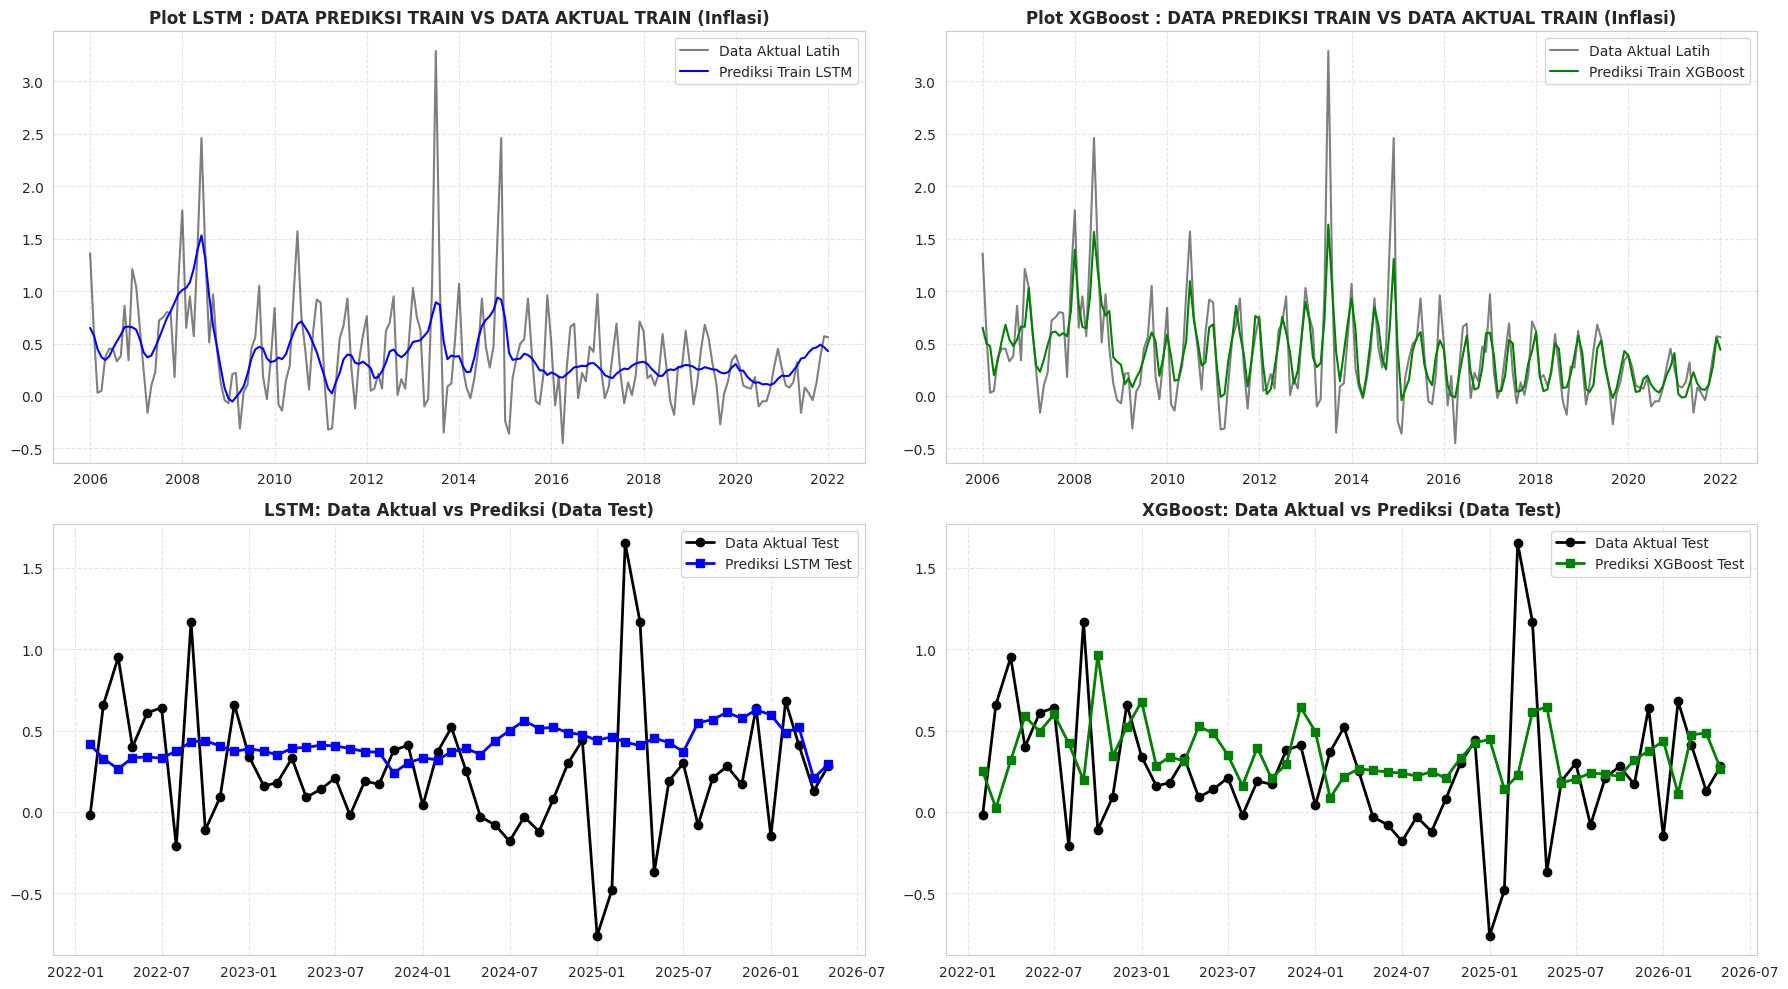

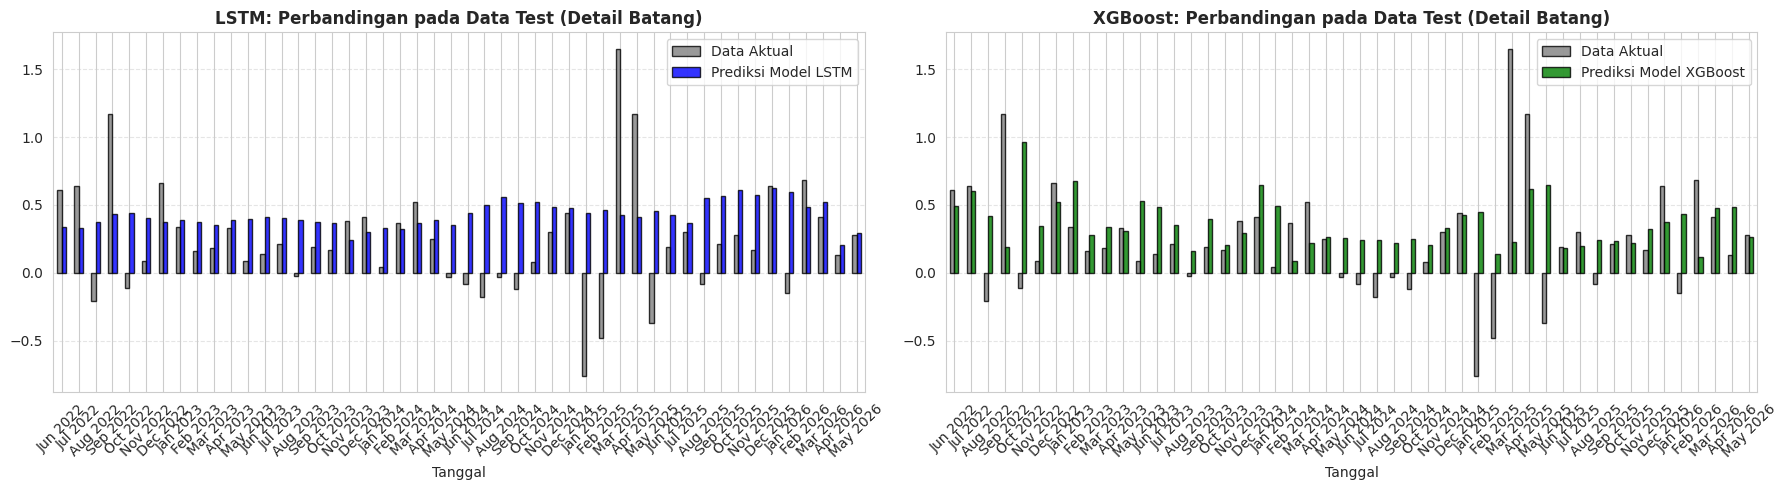

In [26]:
import matplotlib.pyplot as plt

# MENYIMPAN HASIL TEST SET KE EXCEL
tabel_hasil_lstm = pd.DataFrame({
    'Data Aktual'        : jawaban_benar_lstm_asli.flatten(),
    'Prediksi Model LSTM': tebakan_lstm_asli.flatten()
}, index=indeks_uji_lstm)          # FIX: y_uji_lstm (numpy array) → indeks_uji_lstm

tabel_hasil_xgb = pd.DataFrame({
    'Data Aktual'           : jawaban_benar_xgb_asli.flatten(),
    'Prediksi Model XGBoost': tebakan_xgb_asli.flatten()
}, index=y_uji_xgb.index)

tabel_hasil_lstm.to_excel('Prediksi_Test_LSTM.xlsx')
tabel_hasil_xgb.to_excel('Prediksi_Test_XGBoost.xlsx')

# PREDIKSI DATA LATIH (TRAIN SET) UNTUK PLOT
tebakan_latih_lstm_skala = model_terbaik_lstm.predict(X_latih_full, verbose=0)   # FIX: pakai X_latih_full (seluruh train)
tebakan_latih_lstm_asli  = kembalikan_ke_asli_inflasi(tebakan_latih_lstm_skala.reshape(-1, 1), alat_skala_final_lstm)
jawaban_latih_lstm_asli  = kembalikan_ke_asli_inflasi(y_latih_full.reshape(-1, 1), alat_skala_final_lstm)  # FIX: pakai y_latih_full

tebakan_latih_xgb_asli = model_terbaik_xgb.predict(X_latih_xgb)
jawaban_latih_xgb_asli = y_latih_xgb.values

# VISUALISASI GARIS WAKTU (GRID 2x2)
indeks_latih_lstm = data_latih_lstm.index[jumlah_bulan_kebelakang:]

fig, ax = plt.subplots(2, 2, figsize=(18, 10))

# [KIRI ATAS] LSTM Train
ax[0, 0].plot(indeks_latih_lstm, jawaban_latih_lstm_asli, label='Data Aktual Latih', color='black', alpha=0.5, linewidth=1.5)
ax[0, 0].plot(indeks_latih_lstm, tebakan_latih_lstm_asli, label='Prediksi Train LSTM', color='blue', linewidth=1.5)
ax[0, 0].set_title('Plot LSTM : DATA PREDIKSI TRAIN VS DATA AKTUAL TRAIN (Inflasi)', fontweight='bold')
ax[0, 0].legend()
ax[0, 0].grid(True, linestyle='--', alpha=0.5)

# [KANAN ATAS] XGBoost Train
ax[0, 1].plot(y_latih_xgb.index, jawaban_latih_xgb_asli, label='Data Aktual Latih', color='black', alpha=0.5, linewidth=1.5)
ax[0, 1].plot(y_latih_xgb.index, tebakan_latih_xgb_asli, label='Prediksi Train XGBoost', color='green', linewidth=1.5)
ax[0, 1].set_title('Plot XGBoost : DATA PREDIKSI TRAIN VS DATA AKTUAL TRAIN (Inflasi)', fontweight='bold')
ax[0, 1].legend()
ax[0, 1].grid(True, linestyle='--', alpha=0.5)

# [KIRI BAWAH] LSTM Test
ax[1, 0].plot(tabel_hasil_lstm.index, tabel_hasil_lstm['Data Aktual'], label='Data Aktual Test', marker='o', color='black', linewidth=2)
ax[1, 0].plot(tabel_hasil_lstm.index, tabel_hasil_lstm['Prediksi Model LSTM'], label='Prediksi LSTM Test', marker='s', color='blue', linewidth=2)
ax[1, 0].set_title('LSTM: Data Aktual vs Prediksi (Data Test)', fontweight='bold')
ax[1, 0].legend()
ax[1, 0].grid(True, linestyle='--', alpha=0.5)

# [KANAN BAWAH] XGBoost Test
ax[1, 1].plot(tabel_hasil_xgb.index, tabel_hasil_xgb['Data Aktual'], label='Data Aktual Test', marker='o', color='black', linewidth=2)
ax[1, 1].plot(tabel_hasil_xgb.index, tabel_hasil_xgb['Prediksi Model XGBoost'], label='Prediksi XGBoost Test', marker='s', color='green', linewidth=2)
ax[1, 1].set_title('XGBoost: Data Aktual vs Prediksi (Data Test)', fontweight='bold')
ax[1, 1].legend()
ax[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# VISUALISASI GRAFIK BATANG (BAR CHART)
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

format_waktu_lstm = tabel_hasil_lstm.index.strftime('%b %Y')
format_waktu_xgb  = tabel_hasil_xgb.index.strftime('%b %Y')

tabel_hasil_lstm.set_index(format_waktu_lstm).tail(48).plot(kind='bar', ax=ax[0], color=['gray', 'blue'], edgecolor='black', alpha=0.8)
ax[0].set_title('LSTM: Perbandingan pada Data Test (Detail Batang)', fontweight='bold')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

tabel_hasil_xgb.set_index(format_waktu_xgb).tail(48).plot(kind='bar', ax=ax[1], color=['gray', 'green'], edgecolor='black', alpha=0.8)
ax[1].set_title('XGBoost: Perbandingan pada Data Test (Detail Batang)', fontweight='bold')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


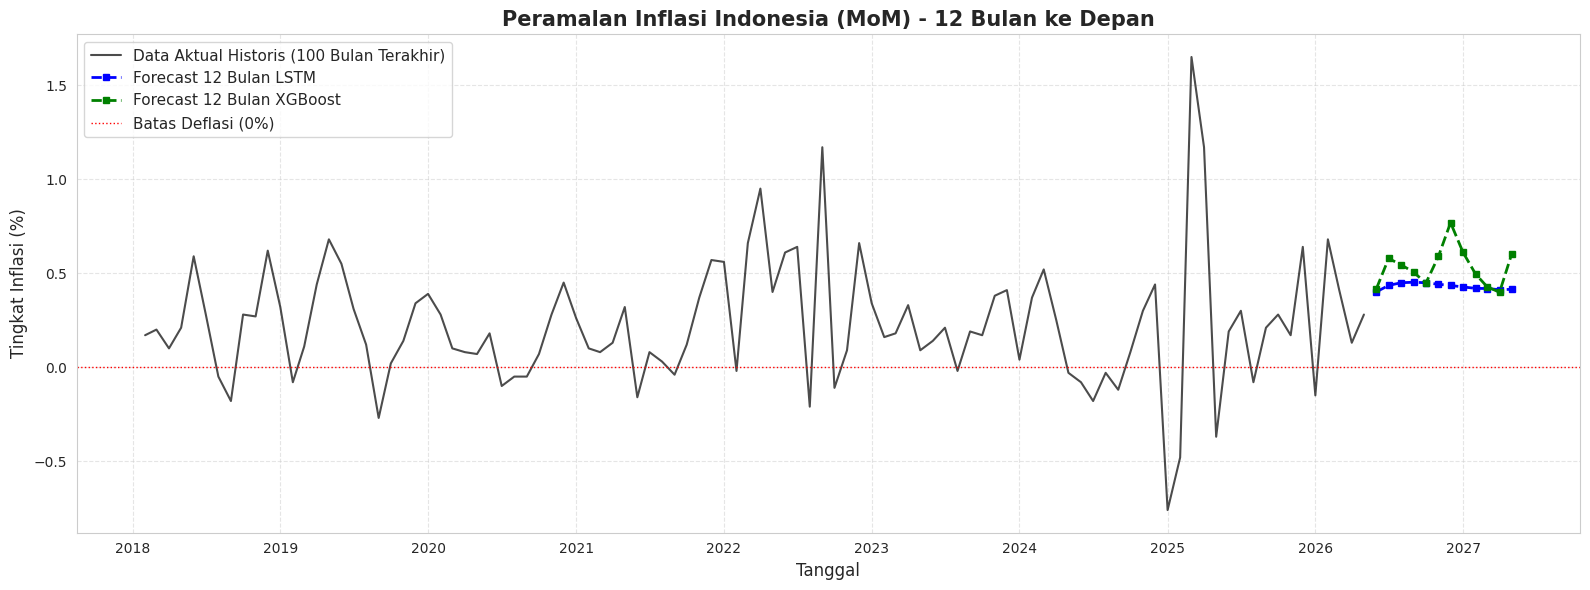

In [27]:
plt.figure(figsize=(16, 6))

# Plot keseluruhan data aktual -sebagian data terakhir agar grafik tidak terlalu padat - dari 2018
plt.plot(df_raw.index[-100:], df_raw['Inflasi_MoM'].iloc[-100:], 
         label='Data Aktual Historis (100 Bulan Terakhir)', color='black', linewidth=1.5, alpha=0.7)

# Plot hasil ramalan 12 bulan ke depan (LSTM & XGBoost)
plt.plot(tabel_ramalan_final.index, tabel_ramalan_final['Ramalan_LSTM'], 
         label='Forecast 12 Bulan LSTM', color='blue', marker='s', markersize=5, linestyle='dashed', linewidth=2)
plt.plot(tabel_ramalan_final.index, tabel_ramalan_final['Ramalan_XGBoost'], 
         label='Forecast 12 Bulan XGBoost', color='green', marker='s', markersize=5, linestyle='dashed', linewidth=2)

# Garis Nol (Batas Deflasi)
plt.axhline(0, color='red', linestyle=':', linewidth=1, label='Batas Deflasi (0%)')


plt.title('Peramalan Inflasi Indonesia (MoM) - 12 Bulan ke Depan', fontsize=15, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Tingkat Inflasi (%)', fontsize=12)


plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

FORECAST INFLASI (MoM) : June 2026
Prediksi Model LSTM    : 0.40%
Prediksi Model XGBoost : 0.42%


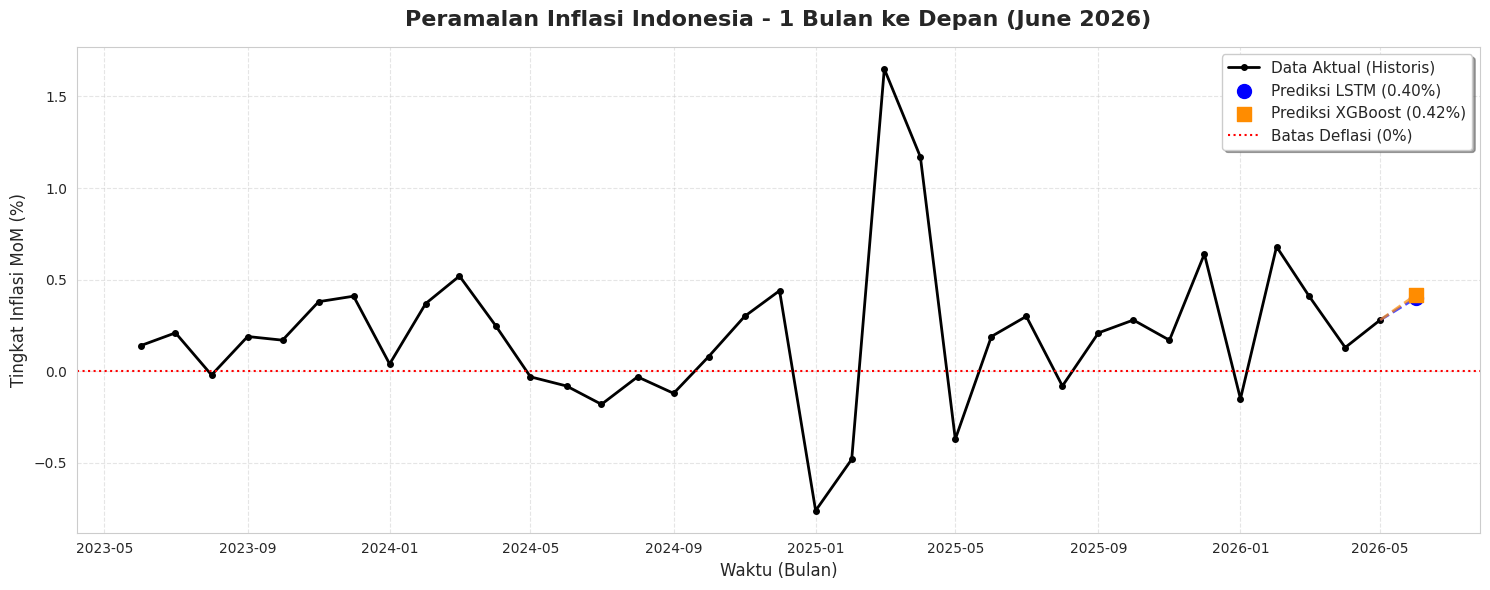

In [28]:
# PREDIKSI 1 BULAN KE DEPAN & VISUALISASI 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


tanggal_terakhir = df_raw.index[-1]
tanggal_prediksi = tanggal_terakhir + pd.DateOffset(months=1)
nilai_aktual_terakhir = df_raw['Inflasi_MoM'].iloc[-1]

# PREDIKSI LSTM (1 BULAN) 
data_terakhir_12_bulan = data_lstm.tail(jumlah_bulan_kebelakang).copy()
input_skala = alat_skala_final_lstm.transform(data_terakhir_12_bulan.values)
input_lstm_3d = input_skala.reshape(1, jumlah_bulan_kebelakang, n_fitur_lstm)
tebakan_lstm_skala = model_terbaik_lstm.predict(input_lstm_3d, verbose=0)
hasil_prediksi_lstm = kembalikan_ke_asli_inflasi(tebakan_lstm_skala, alat_skala_final_lstm)[0]

# PREDIKSI XGBOOST (1 BULAN) 
# PREDIKSI XGBOOST (1 BULAN) 
baris_input = pd.Series(index=X_fitur_xgb.columns, dtype='float64')

# fitur eksternal dari T-1 (nilai aktual di bulan terakhir dataset)
fitur_eksternal_terakhir = df_raw.drop(columns=['Inflasi_MoM']).iloc[-1]
for col in fitur_eksternal_terakhir.index:
    if col in baris_input.index:
        baris_input[col] = fitur_eksternal_terakhir[col]

# Kalender
baris_input['kuartal']   = tanggal_prediksi.quarter
baris_input['bulan_sin'] = np.sin(2 * np.pi * tanggal_prediksi.month / 12.0)
baris_input['bulan_cos'] = np.cos(2 * np.pi * tanggal_prediksi.month / 12.0)

# Lag & Rolling
for i in [1, 2, 3, 6, 12]:
    baris_input[f'inflasi_lag_{i}'] = df_raw['Inflasi_MoM'].iloc[-i]

baris_input['inflasi_rolling_mean_3']  = df_raw['Inflasi_MoM'].iloc[-3:].mean()
baris_input['inflasi_rolling_std_3']   = df_raw['Inflasi_MoM'].iloc[-3:].std()
baris_input['inflasi_rolling_mean_6']  = df_raw['Inflasi_MoM'].iloc[-6:].mean()
baris_input['inflasi_rolling_std_6']   = df_raw['Inflasi_MoM'].iloc[-6:].std()
baris_input['inflasi_rolling_mean_12'] = df_raw['Inflasi_MoM'].iloc[-12:].mean()

df_input = pd.DataFrame([baris_input])
hasil_prediksi_xgb = model_terbaik_xgb.predict(df_input)[0]

print(f"FORECAST INFLASI (MoM) : {tanggal_prediksi.strftime('%B %Y')}")
print(f"Prediksi Model LSTM    : {hasil_prediksi_lstm:.2f}%")
print(f"Prediksi Model XGBoost : {hasil_prediksi_xgb:.2f}%")

 
plt.figure(figsize=(15, 6))

# Plot Data Historis - meampilkan 36 bulan terakhir agar pergerakan terlihat jelas
periode_tampil = 36 
plt.plot(df_raw.index[-periode_tampil:], df_raw['Inflasi_MoM'].iloc[-periode_tampil:], 
         label='Data Aktual (Historis)', color='black', linewidth=2, marker='o', markersize=4)

# garis penghubung dari titik aktual terakhir ke titik prediksi LSTM
plt.plot([tanggal_terakhir, tanggal_prediksi], [nilai_aktual_terakhir, hasil_prediksi_lstm], 
         color='blue', linestyle='--', linewidth=2, alpha=0.7)
# Plot Titik Prediksi LSTM
plt.scatter(tanggal_prediksi, hasil_prediksi_lstm, color='blue', s=100, zorder=5, 
            label=f'Prediksi LSTM ({hasil_prediksi_lstm:.2f}%)')

# garis penghubung dari titik aktual terakhir ke titik prediksi XGBoost
plt.plot([tanggal_terakhir, tanggal_prediksi], [nilai_aktual_terakhir, hasil_prediksi_xgb], 
         color='darkorange', linestyle='--', linewidth=2, alpha=0.7)
# Plot Titik Prediksi XGBoost
plt.scatter(tanggal_prediksi, hasil_prediksi_xgb, color='darkorange', s=100, zorder=5, marker='s',
            label=f'Prediksi XGBoost ({hasil_prediksi_xgb:.2f}%)')

# Garis batas Deflasi (0%)
plt.axhline(0, color='red', linestyle=':', linewidth=1.5, label='Batas Deflasi (0%)')


plt.title(f"Peramalan Inflasi Indonesia - 1 Bulan ke Depan ({tanggal_prediksi.strftime('%B %Y')})", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Waktu (Bulan)", fontsize=12)
plt.ylabel("Tingkat Inflasi MoM (%)", fontsize=12)
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()